# Team 2: Model Development & Tuning

**Team 1 handoff:** `bescom_preprocessed_final.csv` + `scale_columns.json`  
**Team 2 scope:** Data leakage audit → Train/Val/Test split → Scaling → Baseline models → Hyperparameter tuning → SHAP explainability → Final model export

---
## MEMBER C - Hyperparameter Tuning + Cross-Validation

In [23]:
# ─────────────────────────────────────────────────────────────
# CELL 7 · Optuna — XGBoost Hyperparameter Tuning
# ─────────────────────────────────────────────────────────────
# Why Optuna over GridSearchCV?
#   Optuna uses Bayesian TPE (Tree-structured Parzen Estimator)
#   which is smarter than exhaustive grid search — it learns which
#   regions of the hyperparameter space work well and focuses there.
#   For XGBoost with 8 hyperparameters, GridSearch would require
#   thousands of fits. Optuna finds a good solution in 50–80 trials.
#
# Objective: minimise Val MAE
# Data: X_train_sc / y_train for fit; X_val_sc / y_val for evaluate
# Test set: NOT touched here — preserved as final holdout.

def xgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators',    100, 800),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'max_depth'         : trial.suggest_int('max_depth',       3, 10),
        'min_child_weight'  : trial.suggest_int('min_child_weight',1, 10),
        'subsample'         : trial.suggest_float('subsample',     0.50, 1.00),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.40, 1.00),
        'gamma'             : trial.suggest_float('gamma',         0.0, 5.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha',     0.0, 5.0),
        'reg_lambda'        : trial.suggest_float('reg_lambda',    0.5, 5.0),
        'random_state'      : RANDOM_STATE,
        'verbosity'         : 0,
        'eval_metric'       : 'mae',
        'early_stopping_rounds': 20,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(
        X_train_sc, y_train,
        eval_set=[(X_val_sc, y_val)],
        verbose=False
    )
    y_pred_val = model.predict(X_val_sc)
    return mean_absolute_error(y_val, y_pred_val)


print('Starting Optuna XGBoost tuning (75 trials)...')
print('This takes ~3–5 minutes. Please wait.\n')

study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(xgb_objective, n_trials=75, show_progress_bar=True)

best_params = study.best_params
print(f'\nBest Val MAE: {study.best_value:.4f} units')
print('Best hyperparameters:')
for k, v in best_params.items():
    print(f'  {k:<25}: {v}')

Starting Optuna XGBoost tuning (75 trials)...
This takes ~3–5 minutes. Please wait.



  0%|          | 0/75 [00:00<?, ?it/s]


Best Val MAE: 17.5506 units
Best hyperparameters:
  n_estimators             : 733
  learning_rate            : 0.05117666335643335
  max_depth                : 4
  min_child_weight         : 3
  subsample                : 0.9400131173613441
  colsample_bytree         : 0.9987996413583662
  gamma                    : 3.249360433167791
  reg_alpha                : 2.3058837788475612
  reg_lambda               : 3.2081755353994628


  XGBoost (Optuna tuned)        Train R²=0.9512  Val R²=0.9127  Val MAE=17.55  NO

5-Fold Cross-Validation Results (XGBoost tuned):
  R²  per fold : [np.float64(0.9114), np.float64(0.91), np.float64(0.9098), np.float64(0.9126), np.float64(0.9084)]
  R²  mean±std : 0.9104 ± 0.0014
  MAE per fold : [np.float64(17.69), np.float64(17.23), np.float64(17.74), np.float64(17.86), np.float64(17.77)]
  MAE mean±std : 17.66 ± 0.22 units



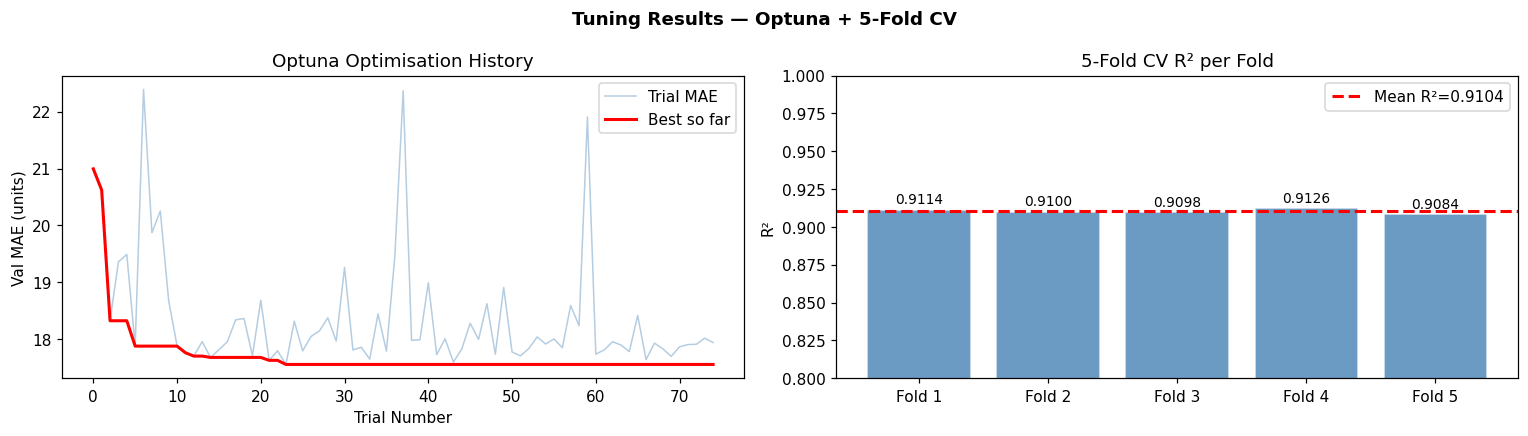

In [24]:
# ─────────────────────────────────────────────────────────────
# CELL 8 · Train Tuned XGBoost + 5-Fold Cross-Validation
# ─────────────────────────────────────────────────────────────
# Step 1: Train final XGBoost with best Optuna params on full train set.
# Step 2: 5-fold CV on (train + val) to get robust R² estimate.
#   CV folds use only train+val — test set never enters CV.

# ── Build tuned model ─────────────────────────────────────────
tuned_params = {
    **best_params,
    'random_state'        : RANDOM_STATE,
    'verbosity'           : 0,
    'eval_metric'         : 'mae',
    'early_stopping_rounds': 20,
}

tuned_xgb = xgb.XGBRegressor(**tuned_params)
tuned_xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=False
)

_, tuned_res = evaluate_model(
    'XGBoost (Optuna tuned)',
    tuned_xgb,
    X_train_sc, y_train, X_val_sc, y_val,
    store=True
)

print()

# ── 5-Fold Cross-Validation on train+val ──────────────────────
# Combine train + val for CV (test stays locked)
X_cv = pd.concat([X_train_sc, X_val_sc], axis=0)
y_cv = pd.concat([y_train,    y_val],    axis=0)

# Use the same tuned params but without early stopping for CV
cv_params = {k: v for k, v in tuned_params.items()
             if k not in ['early_stopping_rounds', 'eval_metric']}
cv_model = xgb.XGBRegressor(**cv_params)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_r2   = cross_val_score(cv_model, X_cv, y_cv, cv=kf, scoring='r2', n_jobs=-1)
cv_mae  = -cross_val_score(cv_model, X_cv, y_cv, cv=kf,
                            scoring='neg_mean_absolute_error', n_jobs=-1)

print('5-Fold Cross-Validation Results (XGBoost tuned):')
print(f'  R²  per fold : {[round(v,4) for v in cv_r2]}')
print(f'  R²  mean±std : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}')
print(f'  MAE per fold : {[round(v,2) for v in cv_mae]}')
print(f'  MAE mean±std : {cv_mae.mean():.2f} ± {cv_mae.std():.2f} units')
print()

# ── Optuna optimisation history plot ──────────────────────────
trials_df = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(trials_df['number'], trials_df['value'], alpha=0.4,
        color='steelblue', lw=1, label='Trial MAE')
running_best = trials_df['value'].cummin()
ax.plot(trials_df['number'], running_best, color='red', lw=2, label='Best so far')
ax.set_xlabel('Trial Number')
ax.set_ylabel('Val MAE (units)')
ax.set_title('Optuna Optimisation History')
ax.legend()

ax2 = axes[1]
cv_fold_labels = [f'Fold {i+1}' for i in range(5)]
bars = ax2.bar(cv_fold_labels, cv_r2, color='steelblue', alpha=0.8, edgecolor='white')
ax2.axhline(cv_r2.mean(), color='red', ls='--', lw=2, label=f'Mean R²={cv_r2.mean():.4f}')
ax2.set_ylim(0.80, 1.00)
ax2.set_ylabel('R²')
ax2.set_title('5-Fold CV R² per Fold')
ax2.legend()
for bar, val in zip(bars, cv_r2):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Tuning Results — Optuna + 5-Fold CV', fontweight='bold')
plt.tight_layout()
plt.show()

  FINAL HOLDOUT TEST SET RESULTS
  Test R²   : 0.9159
  Test MAE  : 17.56 units
  Test RMSE : 22.57 units
  Val  R²   : 0.9127  (for comparison)
  Gap (Val-Test R²): 0.0032  ✅ Good generalisation


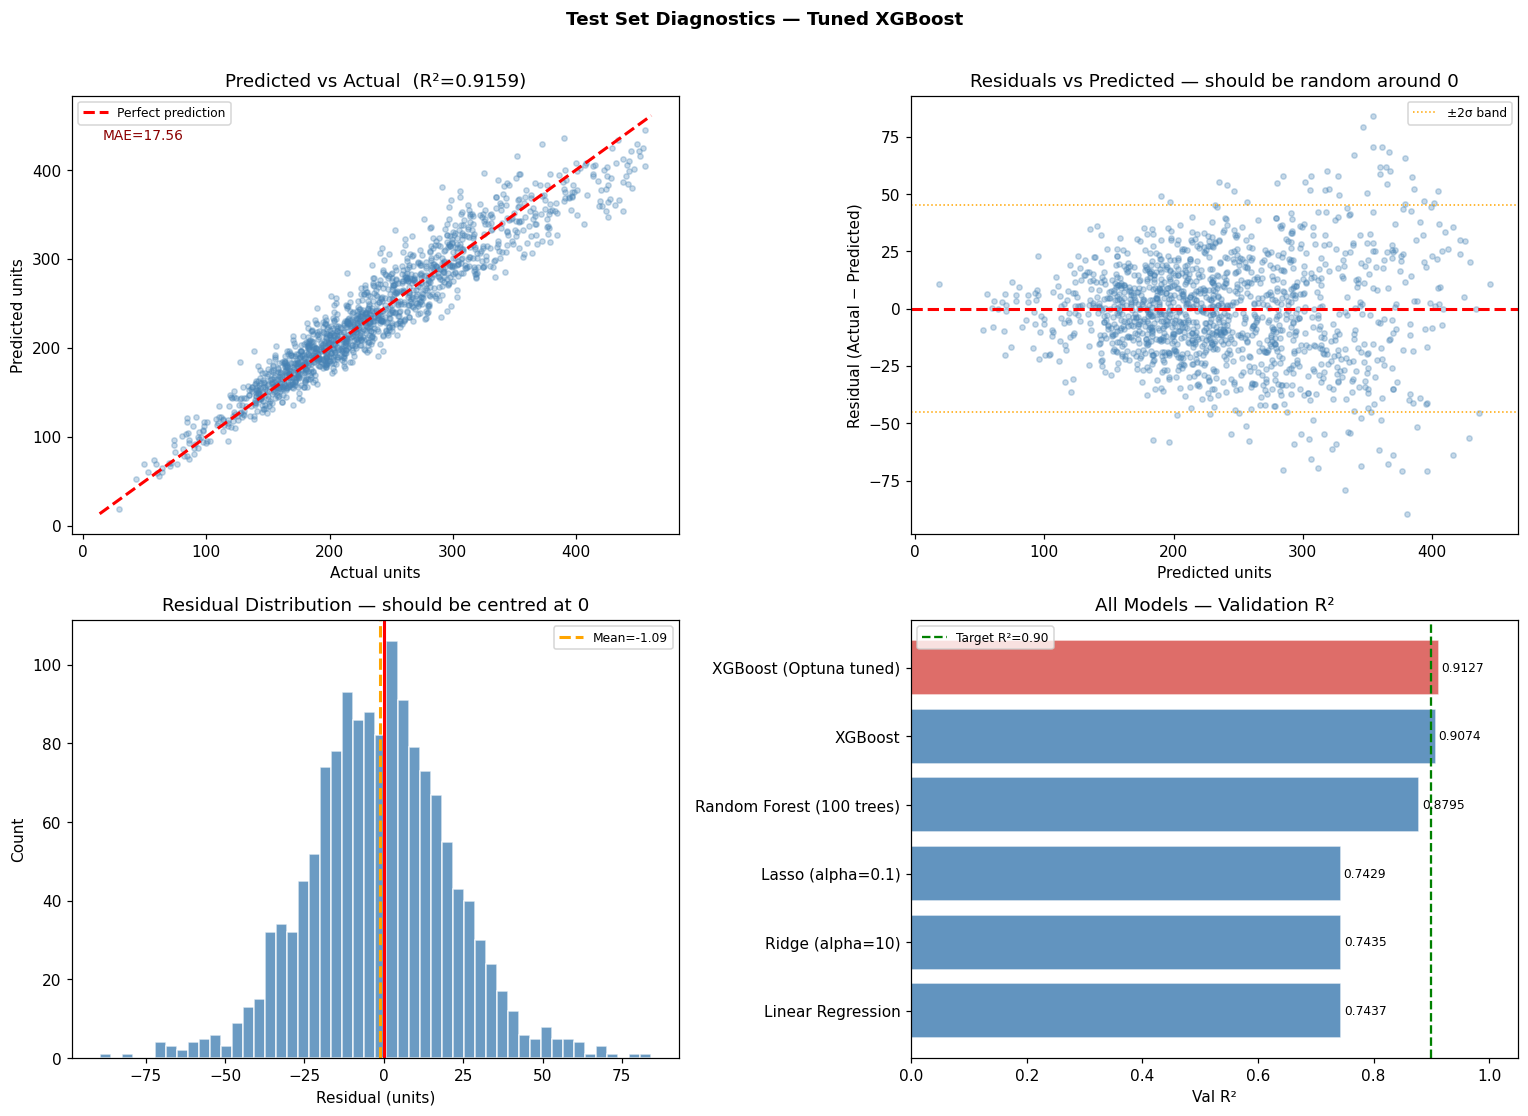

In [25]:
# ─────────────────────────────────────────────────────────────
# CELL 9 · Final Holdout Test Evaluation + Residual Analysis
# ─────────────────────────────────────────────────────────────
# This is the ONE TIME we evaluate on the test set.
# If this number is close to val R² — the model generalises well.
# If it is much lower — we overfit to the validation set during tuning.

y_test_pred = tuned_xgb.predict(X_test_sc)

test_r2   = r2_score(y_test, y_test_pred)
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
residuals = y_test.values - y_test_pred

print('=' * 55)
print('  FINAL HOLDOUT TEST SET RESULTS')
print('=' * 55)
print(f'  Test R²   : {test_r2:.4f}')
print(f'  Test MAE  : {test_mae:.2f} units')
print(f'  Test RMSE : {test_rmse:.2f} units')
print(f'  Val  R²   : {tuned_res["Val R²"]}  (for comparison)')
generalisation_gap = abs(tuned_res['Val R²'] - test_r2)
print(f'  Gap (Val-Test R²): {generalisation_gap:.4f}  '
      + ('✅ Good generalisation' if generalisation_gap < 0.02 else '⚠️ Check for tuning overfit'))
print('=' * 55)

# ── 4-panel diagnostic plot ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y_test, y_test_pred, alpha=0.3, s=12, color='steelblue')
lims = [min(y_test.min(), y_test_pred.min()) - 5,
        max(y_test.max(), y_test_pred.max()) + 5]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect prediction')
ax.set_xlabel('Actual units')
ax.set_ylabel('Predicted units')
ax.set_title(f'Predicted vs Actual  (R²={test_r2:.4f})')
ax.legend(fontsize=8)
ax.text(0.05, 0.90, f'MAE={test_mae:.2f}',
        transform=ax.transAxes, fontsize=9, color='darkred')

# Panel 2: Residuals vs Predicted
ax = axes[0, 1]
ax.scatter(y_test_pred, residuals, alpha=0.3, s=12, color='steelblue')
ax.axhline(0, color='red', lw=2, ls='--')
ax.axhline( 2*residuals.std(), color='orange', ls=':', lw=1)
ax.axhline(-2*residuals.std(), color='orange', ls=':', lw=1,
           label='±2σ band')
ax.set_xlabel('Predicted units')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('Residuals vs Predicted — should be random around 0')
ax.legend(fontsize=8)

# Panel 3: Residual histogram
ax = axes[1, 0]
ax.hist(residuals, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', lw=2)
ax.axvline(residuals.mean(), color='orange', lw=2, ls='--',
           label=f'Mean={residuals.mean():.2f}')
ax.set_xlabel('Residual (units)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution — should be centred at 0')
ax.legend(fontsize=8)

# Panel 4: All models Val R² comparison (updated)
ax = axes[1, 1]
all_results_df = pd.DataFrame(results_log)
colors_bar = ['#d9534f' if 'Optuna' in m else 'steelblue'
              for m in all_results_df['Model']]
bars = ax.barh(all_results_df['Model'], all_results_df['Val R²'],
               color=colors_bar, alpha=0.85, edgecolor='white')
ax.axvline(0.90, color='green', ls='--', lw=1.5, label='Target R²=0.90')
ax.set_xlabel('Val R²')
ax.set_title('All Models — Validation R²')
ax.legend(fontsize=8)
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, all_results_df['Val R²']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Test Set Diagnostics — Tuned XGBoost', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()